# Field Level Inference with Target Projections

## Imports

In [ ]:
# ==== GPU selection ====
from autocvd import autocvd
autocvd(num_gpus = 1)
# ruff: noqa: E402
# =======================

# general
import jax
import jax.numpy as jnp
import optax

# astronomix constants
from astronomix import (
    FINITE_DIFFERENCE,
    FINITE_VOLUME,
    PERIODIC_BOUNDARY,
    BACKWARDS,
)

# astronomix containers
from astronomix import (
    SimulationConfig,
    PositivityConfig,
    BoundarySettings,
    BoundarySettings1D,
    SimulationParams,
    CodeUnits,
)
from astronomix._modules._turbulent_forcing._turbulent_forcing_options import (
    TurbulentForcingConfig,
    TurbulentForcingParams,
)

# astronomix functions
from astronomix import (
    get_registered_variables,
    get_helper_data,
    construct_primitive_state,
    time_integration,
    initialize_interface_fields,
    finalize_config,
)

# units
from astropy import units as u
import astropy.constants as c

# plotting
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pyvista as pv

## Loading the target image

Saving Screenshot 2026-02-10 111809.png to Screenshot 2026-02-10 111809 (3).png


(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

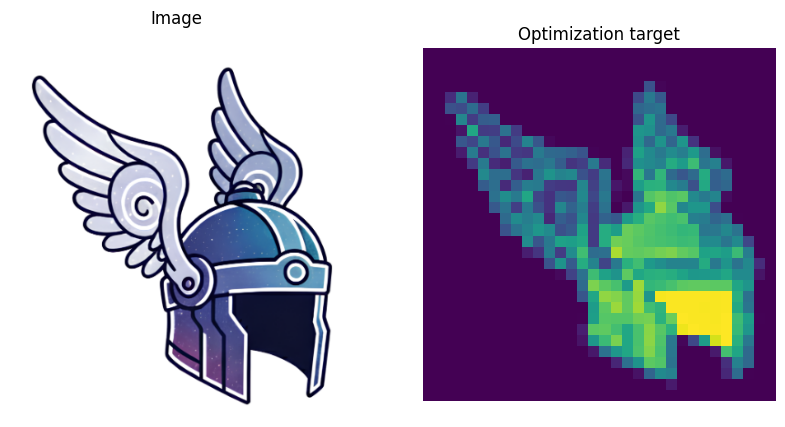

In [ ]:
resolution = 32

from PIL import Image
import jax.numpy as jnp
import matplotlib.pyplot as plt

def load_image(path, height, width, flat_profile = False):
    img = jnp.array(Image.open(path).convert("L"))
    img = 1.0 - img / 255.0 # black → 1, white → 0
    h, w = img.shape

    pad_h = (-h) % height
    pad_w = (-w) % width
    pad = ((pad_h//2, pad_h - pad_h//2),
           (pad_w//2, pad_w - pad_w//2))

    img = jnp.pad(img, pad)
    hp, wp = img.shape

    result = img.reshape(height, hp//height, width, wp//width).mean(axis=(1, 3))

    if flat_profile:
        result = jnp.where(result > 0.01, 1.01, 1.0)
    else:
        # still crunch the range between 1.01 and 1.0
        # but with all the intermediates
        result = 1.0 + (result - 0.01) / (1.0 - 0.01) * 0.01

    return result

# load the optimization target image (placed next to this notebook)
path = "logo.png"

original_rgb = Image.open(path).convert("RGB")
target = load_image(path, resolution, resolution)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(original_rgb)
ax[0].set_title("Image")
ax[0].axis("off")

ax[1].imshow(target, cmap="viridis")
ax[1].set_title("Optimization target")
ax[1].axis("off")

## Field-level inference

### Generation of an initial state

Setting time integrator to RK4_SSP for finite difference solver mode.
Setting boundary handling to PERIODIC_ROLL for finite difference solver mode.
RMS velocity: 39.2670783996582 km / s
Turbulent crossing time: 74703.20646691913 yr


Text(0.5, 1.0, 'pressure')

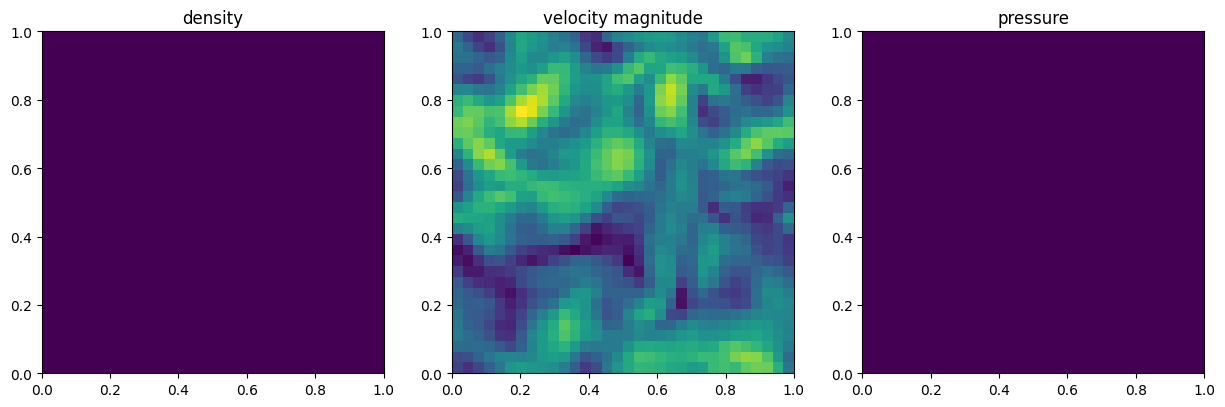

In [ ]:
# simulation settings
gamma = 5/3

# spatial domain
box_size = 1.0
num_cells = resolution

# turbulence
turbulence = True

# otherwise B = 0.0
solver_mode = FINITE_DIFFERENCE
mhd = True

# baseline simulation config
config = SimulationConfig(
    solver_mode = solver_mode,
    mhd = mhd,
    progress_bar = False,
    positivity_config = PositivityConfig(default_positivity_protection = True),
    donate_state = False, # save storage
    differentiation_mode = BACKWARDS,
    dimensionality = 3,
    box_size = box_size,
    num_cells = num_cells,
    turbulent_forcing_config = TurbulentForcingConfig(
        turbulent_forcing = turbulence,
    ),
    boundary_settings =  BoundarySettings(
        BoundarySettings1D(
            left_boundary = PERIODIC_BOUNDARY,
            right_boundary = PERIODIC_BOUNDARY
        ),
        BoundarySettings1D(
            left_boundary = PERIODIC_BOUNDARY,
            right_boundary = PERIODIC_BOUNDARY
        ),
        BoundarySettings1D(
            left_boundary = PERIODIC_BOUNDARY,
            right_boundary = PERIODIC_BOUNDARY
        )
    ),
)

# get the variable registry
registered_variables = get_registered_variables(config)

# unit setup
code_length = 3 * u.parsec
code_mass = 100 * u.M_sun
code_velocity = 100 * u.km / u.s
code_units = CodeUnits(code_length, code_mass, code_velocity)

# time domain
C_CFL = 0.8

# initial state
n_h = 2 # cm^-3
rho_0 = n_h * c.m_p / u.cm**3
p_0 = 3e4 * u.K / u.cm**3 * c.k_B

dE_dt_turb = 4.3e34 * u.erg / u.s

params = SimulationParams(
    C_cfl = C_CFL,
    dt_max = 0.1,
    gamma = gamma,
    # currently only active for the finite diff solver
    minimum_density=(1e-2 * rho_0).to(code_units.code_density).value,
    minimum_pressure=(1e-2 * p_0).to(code_units.code_pressure).value,
    turbulent_forcing_params = TurbulentForcingParams(
        energy_injection_rate = dE_dt_turb.to(code_units.code_energy / code_units.code_time).value,
    ),
)

rho = jnp.ones((config.num_cells, config.num_cells, config.num_cells)) * rho_0.to(code_units.code_density).value
u_x = jnp.zeros((config.num_cells, config.num_cells, config.num_cells))
u_y = jnp.zeros((config.num_cells, config.num_cells, config.num_cells))
u_z = jnp.zeros((config.num_cells, config.num_cells, config.num_cells))
p = jnp.ones((config.num_cells, config.num_cells, config.num_cells)) * p_0.to(code_units.code_pressure).value

if mhd:
    B_0 = 13.5 * u.microgauss / c.mu0**0.5
    B_0 = B_0.to(code_units.code_magnetic_field).value
else:
    B_0 = 0.0

B_x = jnp.ones((config.num_cells, config.num_cells, config.num_cells)) * B_0
B_y = jnp.zeros((config.num_cells, config.num_cells, config.num_cells))
B_z = jnp.zeros((config.num_cells, config.num_cells, config.num_cells))
bxb, byb, bzb = initialize_interface_fields(B_x, B_y, B_z)

# construct primitive state
initial_state = construct_primitive_state(
    config = config,
    registered_variables=registered_variables,
    density = rho,
    velocity_x = u_x,
    velocity_y = u_y,
    velocity_z = u_z,
    gas_pressure = p,
    magnetic_field_x = B_x,
    magnetic_field_y = B_y,
    magnetic_field_z = B_z,
    interface_magnetic_field_x = bxb,
    interface_magnetic_field_y = byb,
    interface_magnetic_field_z = bzb,
)

config = finalize_config(config, initial_state.shape)

t_final = 24 * 1e4 * u.yr
t_end = t_final.to(code_units.code_time).value

# set the final time
params = params._replace(
    t_end = t_end,
)

# running a small turbulent simulation
turb_state = time_integration(initial_state, config, params, registered_variables)

# calculate the rms velocity and turbulent crossing time
rms_velocity = jnp.sqrt(jnp.mean(turb_state[registered_variables.velocity_index.x]**2 + turb_state[registered_variables.velocity_index.y]**2 + turb_state[registered_variables.velocity_index.z]**2))
rms_velocity = (rms_velocity * code_units.code_velocity).to(u.km/u.s)
crossing_time = box_size * code_length / rms_velocity
print(f"RMS velocity: {rms_velocity}")
print(f"Turbulent crossing time: {(crossing_time).to(u.yr)}")

# keep the turbulent density / pressure / magnetic field and optimize only the
# velocity on top of them (matching the field-level-inference script)
reset_to_uniform = False
if reset_to_uniform:
    turb_state = construct_primitive_state(
        config = config,
        registered_variables=registered_variables,
        density = rho,
        velocity_x = turb_state[registered_variables.velocity_index.x],
        velocity_y = turb_state[registered_variables.velocity_index.y],
        velocity_z = turb_state[registered_variables.velocity_index.z],
        gas_pressure = p,
        magnetic_field_x = B_x,
        magnetic_field_y = B_y,
        magnetic_field_z = B_z,
        interface_magnetic_field_x = bxb,
        interface_magnetic_field_y = byb,
        interface_magnetic_field_z = bzb,
    )

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# equal aspect ratio
ax1.set_aspect('equal', 'box')
ax2.set_aspect('equal', 'box')
ax3.set_aspect('equal', 'box')

z_level = num_cells // 2

ax1.imshow(turb_state[registered_variables.density_index, :, :, z_level].T, origin = "lower", extent = [0, 1, 0, 1], norm = LogNorm())
ax1.set_title("density")

ax2.imshow(jnp.sqrt(turb_state[registered_variables.velocity_index.x, :, :, z_level]**2 + turb_state[registered_variables.velocity_index.y, :, :, z_level]**2 + turb_state[registered_variables.velocity_index.z, :, :, z_level]**2).T, origin = "lower", extent = [0, 1, 0, 1])
ax2.set_title("velocity magnitude")

ax3.imshow(turb_state[registered_variables.pressure_index, :, :, z_level].T, origin = "lower", extent = [0, 1, 0, 1], norm = LogNorm())
ax3.set_title("pressure")

### Adapting the target to the total mass in the simulation

In [ ]:
total_mass = jnp.sum(turb_state[registered_variables.density_index])
target = target / jnp.sum(target) * total_mass

### Adapt the simulation, turn off the turbulent driving

In [ ]:
config = config._replace(
    differentiation_mode = BACKWARDS,
    progress_bar = False,
    num_checkpoints = 10,
    turbulent_forcing_config = TurbulentForcingConfig(
        turbulent_forcing = False,
    ),
)

t_final = crossing_time / 2
t_end = t_final.to(code_units.code_time).value
print(t_end)

params = params._replace(
    t_end = t_end,
)

0.3183328250901601


### Velocity Optimization

#### Define the loss

In [ ]:
def loss(velocity):

  # set the current velocity
  initial_state = turb_state.at[registered_variables.velocity_index.x].set(velocity[0])
  initial_state = initial_state.at[registered_variables.velocity_index.y].set(velocity[1])
  initial_state = initial_state.at[registered_variables.velocity_index.z].set(velocity[2])

  # integrate in time
  final_state = time_integration(initial_state, config, params, registered_variables)

  # get the final density
  density = final_state[registered_variables.density_index]

  # sum density along z
  projected_density = jnp.sum(density, axis = (2,))
  density_loss = jnp.mean(jnp.square(projected_density - target))
  return density_loss

initial_loss = loss(turb_state[registered_variables.density_index])
print(f"Initial loss: {initial_loss}")

Initial loss: 1.2778000382240862e-06


#### Optimization

In [ ]:
current_velocity = jnp.array([
  turb_state[registered_variables.velocity_index.x],
  turb_state[registered_variables.velocity_index.y],
  turb_state[registered_variables.velocity_index.z],
])

# optimizer setup
learning_rate = 1e-2
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(current_velocity)

# gradient
grad_loss = jax.grad(loss)

best_loss = initial_loss
best_velocity = current_velocity

# optimization
num_steps = 150
for step in range(num_steps):
    grads = grad_loss(current_velocity)
    updates, opt_state = optimizer.update(grads, opt_state)
    current_velocity = optax.apply_updates(current_velocity, updates)

    current_loss = loss(current_velocity)
    print(f"Step {step}: loss = {current_loss}")

    if current_loss < best_loss:
        best_loss = current_loss
        best_velocity = current_velocity

best_state = turb_state.at[registered_variables.velocity_index.x].set(best_velocity[0])
best_state = best_state.at[registered_variables.velocity_index.y].set(best_velocity[1])
best_state = best_state.at[registered_variables.velocity_index.z].set(best_velocity[2])

print("Optimization finished.")

final_loss = loss(best_velocity)
print(f"Final loss: {final_loss}")

Step 0: loss = 0.004571446217596531
Step 1: loss = 0.0026402687653899193
Step 2: loss = 0.001482547027990222
Step 3: loss = 0.0008397266501560807
Step 4: loss = 0.0005258036544546485
Step 5: loss = 0.0004127580614294857
Step 6: loss = 0.00041129085002467036
Step 7: loss = 0.00045997940469533205
Step 8: loss = 0.0005156851257197559
Step 9: loss = 0.0005503275315277278
Step 10: loss = 0.0005505955778062344
Step 11: loss = 0.0005173764657229185
Step 12: loss = 0.00046119262697175145
Step 13: loss = 0.0003956285654567182
Step 14: loss = 0.00033258856274187565
Step 15: loss = 0.00027917823172174394
Step 16: loss = 0.00023712257097940892
Step 17: loss = 0.0002044794528046623
Step 18: loss = 0.00017783869407139719
Step 19: loss = 0.00015424629964400083
Step 20: loss = 0.00013216731895226985
Step 21: loss = 0.0001114587503252551
Step 22: loss = 9.282383689424023e-05
Step 23: loss = 7.733923848718405e-05
Step 24: loss = 6.59480137983337e-05
Step 25: loss = 5.9051559219369665e-05
Step 26: loss =

In [ ]:
final_state = time_integration(best_state, config, params, registered_variables)

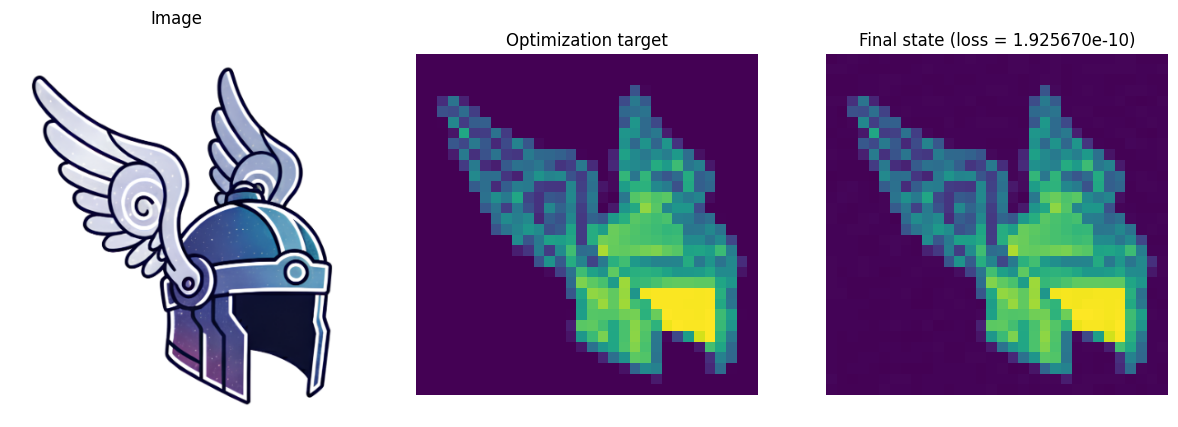

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(original_rgb)
ax[0].set_title("Image")
ax[0].axis("off")

ax[1].imshow(target, cmap="viridis")
ax[1].set_title("Optimization target")
ax[1].axis("off")

ax[2].imshow(jnp.sum(final_state[registered_variables.density_index], axis = (2,)))
ax[2].set_title(f"Final state (loss = {loss(best_velocity):3e})")
ax[2].axis("off")

plt.savefig("overview.png", dpi = 600)

### Animation

In [ ]:
config = config._replace(
    activate_snapshot_callback = True,
    num_snapshots = 200
)

import os

# create folder for frames
os.makedirs('frames', exist_ok=True)

# empty the folder
for filename in os.listdir('frames'):
  os.remove(os.path.join('frames', filename))

def save_frame(
  time,
  state,
  registered_variables
):

    plot_3D = True

    def plot_slices(density, time):

        print(f"plotting slice at t = {time}")

        if plot_3D:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

            # 3D volumetric rendering in pyvista
            density_3d = np.asarray(density)
            grid = pv.ImageData()
            grid.dimensions = np.array(density_3d.shape) + 1
            grid.cell_data["density"] = density_3d.ravel(order="F")

            plotter = pv.Plotter(off_screen=True, window_size=(700, 700))
            plotter.add_volume(
                    grid,
                    scalars="density",
                    cmap="viridis",
                    clim=(0.01, 0.02),
                    opacity="sigmoid",
                    blending="composite",
                    shade=True,
            )
            plotter.camera_position = "iso"
            volume_img = plotter.screenshot(return_img=True)
            plotter.close()

            ax1.imshow(volume_img)
            ax1.set_title("volumetric rendering")
            ax1.set_xticks([])
            ax1.set_yticks([])

            # projection
            ax2.set_aspect('equal', 'box')
            ax2.set_xticks([])
            ax2.set_yticks([])
            ax2.imshow(np.sum(density_3d, axis = (2,)))
            ax2.set_title("density projection")
        else:
            fig, ax2 = plt.subplots(1, 1, figsize=(4, 4))

            # projection
            ax2.set_aspect('equal', 'box')
            ax2.set_xticks([])
            ax2.set_yticks([])
            ax2.imshow(density)
            ax2.set_title("density projection")

        fig.savefig(
            f"frames/frame{time}.png",
            dpi=150,
            bbox_inches="tight",
            pad_inches=0
        )

        plt.close(fig)

    if plot_3D:
        jax.debug.callback(
            plot_slices,
            state[registered_variables.density_index], time,
        )
    else:
        jax.debug.callback(
            plot_slices,
            jnp.sum(state[registered_variables.density_index], axis = (2,)), time,
        )

In [ ]:
final_state = time_integration(best_state, config, params, registered_variables, save_frame)

plotting slice at t = 0.0
plotting slice at t = 0.006724408362060785
plotting slice at t = 0.013539919629693031
plotting slice at t = 0.02046404965221882
plotting slice at t = 0.027501728385686874
plotting slice at t = 0.03464844822883606
plotting slice at t = 0.04189566522836685
plotting slice at t = 0.04921728000044823
plotting slice at t = 0.05660725757479668
plotting slice at t = 0.06403987109661102
plotting slice at t = 0.0715370625257492
plotting slice at t = 0.07910574972629547
plotting slice at t = 0.08672761172056198
plotting slice at t = 0.09437839686870575
plotting slice at t = 0.10209611803293228
plotting slice at t = 0.10989398509263992
plotting slice at t = 0.11774787306785583
plotting slice at t = 0.125610813498497
plotting slice at t = 0.1334761530160904
plotting slice at t = 0.1413658857345581
plotting slice at t = 0.14929142594337463
plotting slice at t = 0.1572694480419159
plotting slice at t = 0.1653154194355011
plotting slice at t = 0.17344056069850922
plotting sli

GIF created at: simulation_animation.gif


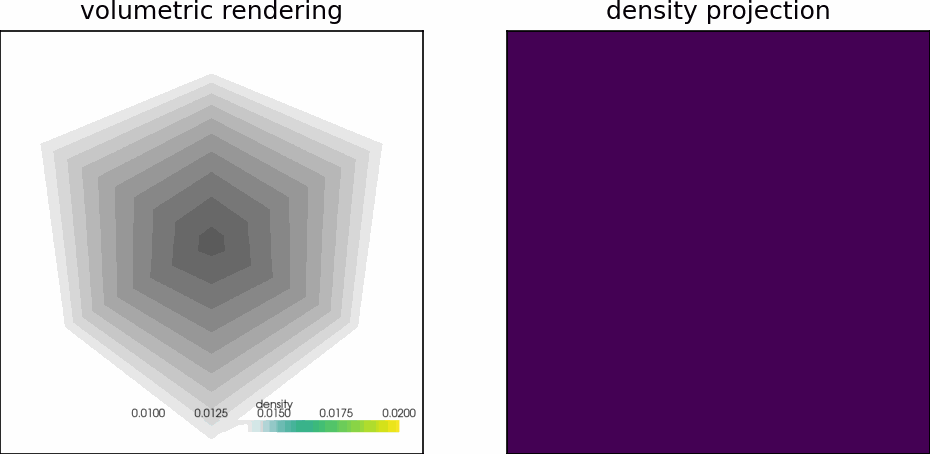

In [ ]:
import imageio.v3 as iio
import os
import re

def get_sorted_frames(directory):
    files = [f for f in os.listdir(directory) if f.endswith('.png')]
    # Extract numerical timestamp from filename (e.g., frame0.123.png -> 0.123)
    # and sort by it
    files.sort(key=lambda f: float(re.search(r'frame([0-9.]+)\.png', f).group(1)))
    return [os.path.join(directory, f) for f in files]

all_frames = get_sorted_frames('frames')

# Read all images into a list
images = [iio.imread(frame) for frame in all_frames]

# Create GIF
gif_path = 'simulation_animation.gif'
iio.imwrite(gif_path, images, duration=int(1000/30))

print(f"GIF created at: {gif_path}")

from IPython.display import Image
Image(filename='simulation_animation.gif')